# 04-High-Throughput Serving Architecture (vLLM)

Lesson 03 measured the physics of a single Hugging Face TGI-style server: prefill is compute-bound, decode is memory-bandwidth-bound, and batching decode steps together is nearly free until the GPU crosses the compute/memory roofline ridge point. That lesson batched requests the naive way -- a fixed static batch, padded to the longest sequence, held together until every member finishes. **vLLM** exists because that naive batching strategy wastes the one resource that actually caps concurrency on a GPU: memory for the KV-cache.

This lesson goes inside vLLM's core contribution, **PagedAttention**: a virtual-memory-style block allocator for the KV-cache that eliminates the fragmentation a naive contiguous allocation suffers, paired with **continuous (iteration-level) batching**, which admits and evicts requests every decode step instead of waiting for a whole batch to drain. Together they are the reason vLLM sustains far higher request concurrency than a framework built on static batching, for exactly the same GPU and exactly the same model.


## 1. The Physics of Paged, Block-Based KV-Cache Memory

### Why naive contiguous allocation wastes memory

A serving engine must reserve enough KV-cache memory for a sequence's *entire* future length before it starts, because tensors in a contiguous allocator cannot be resized in place without a costly copy. Given a maximum context length $L_{max}$ and per-token KV footprint $b$ bytes, naive allocation reserves

$$
M_{\text{naive}}(\text{seq}) = L_{max} \cdot b
$$

for every admitted sequence, regardless of how many tokens $n \ll L_{max}$ it actually ends up using. The wasted memory per sequence is $(L_{max} - n) \cdot b$ -- **internal fragmentation** that grows without bound as $L_{max}$ grows, and it is paid up front even for a sequence that terminates after ten tokens.

### PagedAttention: block-based virtual memory for the KV-cache

PagedAttention borrows the OS's paging trick directly: it partitions the KV-cache into fixed-size **physical blocks** of $B$ tokens each, and gives every sequence a **block table** -- a list mapping that sequence's *logical* block index to a *physical* block index, exactly like a page table maps virtual pages to physical frames. A sequence only holds as many physical blocks as it currently needs:

$$
n_{\text{blocks}}(n) = \left\lceil \frac{n}{B} \right\rceil, \qquad M_{\text{paged}}(\text{seq}) = n_{\text{blocks}}(n) \cdot B \cdot b
$$

New blocks are allocated on demand as the sequence grows past a block boundary, and freed the instant the sequence finishes -- there is no upfront reservation for tokens that may never be generated.

### The physical addressing formula

For logical token position $p$ inside a sequence, PagedAttention computes which physical block holds it and the offset within that block:

$$
\text{block\_table}[\,\lfloor p / B \rfloor\,] = \text{phys\_id}, \qquad \text{offset} = p \bmod B
$$

$$
\text{address}(p) = \text{phys\_id} \cdot (B \cdot b) + (p \bmod B) \cdot b
$$

The attention kernel reads each sequence's KV vectors by walking its block table, so physical blocks belonging to one sequence need not be contiguous in device memory at all -- exactly as a process's physical memory pages need not be contiguous in RAM.

### The fragmentation bound

Because a block is only allocated when the sequence actually needs it, waste is bounded by *at most one partially-filled block* per sequence, not by the gap to $L_{max}$:

$$
\text{waste}_{\text{paged}}(n) = n_{\text{blocks}}(n) \cdot B - n \; < \; B
$$

independent of $L_{max}$. For a typical block size $B = 16$, worst-case waste per sequence is 15 tokens -- versus a naive allocator's waste of up to $L_{max} - 1$ tokens, which can be thousands.

### Effective concurrency under a fixed memory budget

Given a fixed KV-cache memory budget $M$, the number of physical blocks available is $N_{\text{blocks}} = \lfloor M / (B \cdot b) \rfloor$. Naive allocation can admit at most

$$
K_{\text{naive}} = \left\lfloor \frac{M}{L_{max} \cdot b} \right\rfloor
$$

concurrent sequences, set by the *worst case* length. PagedAttention can admit sequences until physical blocks run out, $\sum_{\text{seq}} n_{\text{blocks}}(n_{\text{seq}}) \le N_{\text{blocks}}$, which for typical short-to-medium sequences and a large $L_{max}$ allows dramatically higher concurrency from the *same* GPU -- this is the entire mechanism behind vLLM's throughput advantage.

### Continuous batching

Static batching runs a fixed cohort of requests until the *longest* one finishes, wasting GPU cycles on padding for every request that finished early. Continuous batching instead re-evaluates the active batch every decode iteration: any sequence that just finished is evicted and its blocks freed immediately, and any queued request that now fits in the freed blocks is admitted in the very next iteration -- keeping the GPU's batch as full as memory allows at all times, rather than only between whole-batch boundaries.


## 2. Imperative Execution: A Genuine PagedAttention Block Allocator

`vllm` is not installed in this sandbox and requires a server-class GPU driver stack this environment does not have, so we cannot launch a real vLLM engine. Instead we implement PagedAttention's actual block-table allocator in Python -- the same block/offset addressing scheme described above -- and drive it with a genuine discrete-event simulation of a continuous-batching scheduler processing a stream of variable-length requests, comparing it against a naive contiguous allocator under an identical memory budget.


In [1]:
# Required installations: pip install vllm  (server-class GPU stack; not available in this sandbox)
import numpy as np
from transformers import AutoConfig

print("--- 🚀 Initializing PagedAttention Block-Allocator Sandbox ---")

try:
    import vllm  # noqa: F401
    print("✅ vllm import succeeded -- a real engine could be constructed here.")
except Exception as e:
    print(f"⚠️ vllm not available ({type(e).__name__}); running a genuine toy PagedAttention "
          f"block-allocator simulation instead of a live engine.")

np.random.seed(4)

# 1. 📐 Real per-token KV-cache footprint, computed from GPT-2's actual published config
cfg = AutoConfig.from_pretrained("gpt2")
n_layer, n_embd = cfg.n_layer, cfg.n_embd
bytes_per_elem = 2  # fp16 KV-cache
bytes_per_token = 2 * n_layer * n_embd * bytes_per_elem  # 2 for K and V
print(f"📐 GPT-2 config: n_layer={n_layer}, n_embd={n_embd} -> KV footprint = {bytes_per_token} bytes/token")

BLOCK_SIZE = 16          # tokens per physical block (vLLM's real default)
MEM_BUDGET = 2_000_000_000  # 2 GB hypothetical KV-cache memory budget
NUM_BLOCKS = MEM_BUDGET // (BLOCK_SIZE * bytes_per_token)
MAX_SEQ_LEN = 1024        # GPT-2's context window -- what naive allocation must reserve for
print(f"📦 Physical blocks available under a {MEM_BUDGET/1e9:.1f} GB budget: {NUM_BLOCKS} "
      f"(block_size={BLOCK_SIZE} tokens)")


class PagedKVCacheAllocator:
    """A genuine block-table allocator implementing PagedAttention's addressing scheme."""

    def __init__(self, num_blocks, block_size):
        self.block_size = block_size
        self.free_blocks = list(range(num_blocks))
        self.block_tables = {}  # seq_id -> [physical_block_ids]

    def blocks_needed(self, num_tokens):
        return -(-num_tokens // self.block_size)  # ceil division

    def grow(self, seq_id, new_len):
        """Grow seq_id's block table until it covers new_len tokens. Returns False on OOM."""
        table = self.block_tables.setdefault(seq_id, [])
        while len(table) < self.blocks_needed(new_len):
            if not self.free_blocks:
                return False
            table.append(self.free_blocks.pop())
        return True

    def free(self, seq_id):
        blocks = self.block_tables.pop(seq_id, [])
        self.free_blocks.extend(blocks)

    def blocks_in_use(self):
        return sum(len(t) for t in self.block_tables.values())


# 2. 🌊 Discrete-event simulation: a Poisson stream of requests hitting a continuous-batching scheduler
N_REQUESTS = 240
interarrival = np.random.exponential(scale=1.4, size=N_REQUESTS)
arrival_ticks = np.cumsum(interarrival).astype(int)
prompt_lens = np.random.randint(20, 200, size=N_REQUESTS)
gen_lens = np.random.randint(10, 300, size=N_REQUESTS)
target_lens = prompt_lens + gen_lens

allocator = PagedKVCacheAllocator(NUM_BLOCKS, BLOCK_SIZE)
waiting, active, completed = [], {}, []
queue_wait_ticks = {}
peak_concurrency = 0
peak_blocks_used = 0
snapshot = None
SNAPSHOT_TICK = 150
T_MAX = int(arrival_ticks.max()) + int(target_lens.max()) + 5

for tick in range(T_MAX):
    # admit new arrivals into the waiting queue
    newly_arrived = np.where(arrival_ticks == tick)[0]
    for idx in newly_arrived:
        waiting.append(int(idx))
        queue_wait_ticks[int(idx)] = tick

    # try to admit waiting requests (prefill) in FCFS order -- continuous batching's admission step
    still_waiting = []
    for idx in waiting:
        if allocator.grow(idx, int(prompt_lens[idx])):
            active[idx] = int(prompt_lens[idx])
            queue_wait_ticks[idx] = tick - queue_wait_ticks[idx]
        else:
            still_waiting.append(idx)
    waiting = still_waiting

    # decode step: grow every active sequence by one token
    finished_now = []
    for idx, cur_len in list(active.items()):
        new_len = cur_len + 1
        if allocator.grow(idx, new_len):
            active[idx] = new_len
            if new_len >= target_lens[idx]:
                finished_now.append(idx)
        # if grow fails (OOM), the sequence simply stalls this tick -- real backpressure
    for idx in finished_now:
        allocator.free(idx)
        completed.append(idx)
        del active[idx]

    peak_concurrency = max(peak_concurrency, len(active))
    peak_blocks_used = max(peak_blocks_used, allocator.blocks_in_use())
    if tick == SNAPSHOT_TICK:
        snapshot = {sid: list(blocks) for sid, blocks in allocator.block_tables.items()}

avg_queue_wait = float(np.mean(list(queue_wait_ticks.values()))) if queue_wait_ticks else 0.0

# 3. 📏 Naive contiguous allocator's theoretical capacity under the SAME memory budget
naive_capacity = NUM_BLOCKS * BLOCK_SIZE // MAX_SEQ_LEN
naive_waste_tokens = sum(int(MAX_SEQ_LEN - min(int(t), MAX_SEQ_LEN)) for t in target_lens)
paged_waste_tokens = sum(
    allocator.blocks_needed(int(t)) * BLOCK_SIZE - int(t) for t in target_lens[completed]
)

print(f"\n✅ Simulation complete: {len(completed)}/{N_REQUESTS} requests fully served over {T_MAX} ticks")
print(f"🔍 Peak concurrent sequences under PagedAttention: {peak_concurrency}")
print(f"🔍 Naive contiguous allocator's static capacity (same {NUM_BLOCKS*BLOCK_SIZE} tokens of memory): {naive_capacity}")
print(f"🔍 Mean queueing delay before admission (paged): {avg_queue_wait:.2f} ticks")


--- 🚀 Initializing PagedAttention Block-Allocator Sandbox ---
⚠️ vllm not available (ModuleNotFoundError); running a genuine toy PagedAttention block-allocator simulation instead of a live engine.


📐 GPT-2 config: n_layer=12, n_embd=768 -> KV footprint = 36864 bytes/token
📦 Physical blocks available under a 2.0 GB budget: 3390 (block_size=16 tokens)

✅ Simulation complete: 240/240 requests fully served over 841 ticks
🔍 Peak concurrent sequences under PagedAttention: 111
🔍 Naive contiguous allocator's static capacity (same 54240 tokens of memory): 52
🔍 Mean queueing delay before admission (paged): 0.00 ticks


## 3. Auditing Memory Utilization: Paged vs. Naive Allocation

The simulation above ran an actual block allocator against a real request stream. We now audit the headline numbers a serving engineer cares about: how much higher is achievable concurrency, and how much smaller is fragmentation waste, when memory is paged instead of reserved up front.


In [2]:
print("--- 🧮 PagedAttention vs. Naive Contiguous Allocation Audit ---\n")

concurrency_gain = peak_concurrency / max(naive_capacity, 1)
frag_pct_paged = 100.0 * paged_waste_tokens / max(sum(int(t) for t in target_lens[completed]), 1)
frag_pct_naive = 100.0 * naive_waste_tokens / max(sum(int(MAX_SEQ_LEN) for _ in target_lens), 1)
peak_block_utilization = 100.0 * peak_blocks_used / NUM_BLOCKS

header = f"{'Metric':<42}{'Naive Contiguous':<20}{'PagedAttention':<20}"
print(header)
print("-" * len(header))
print(f"{'Physical blocks available':<42}{NUM_BLOCKS:<20}{NUM_BLOCKS:<20}")
print(f"{'Max/peak concurrent sequences':<42}{naive_capacity:<20}{peak_concurrency:<20}")
frag_naive_str = f"{frag_pct_naive:.1f}%"
frag_paged_str = f"{frag_pct_paged:.1f}%"
print(f"{'Fragmentation waste (% of reserved mem)':<42}{frag_naive_str:<20}{frag_paged_str:<20}")
print(f"{'Requests fully served':<42}{'n/a (static batch)':<20}{len(completed):<20}")
print(f"{'Peak physical block utilization':<42}{'100.0% (fixed)':<20}{peak_block_utilization:<19.1f}%")
print(f"{'Mean admission queueing delay (ticks)':<42}{'n/a':<20}{avg_queue_wait:<20.2f}")

print("\n[OPERATIONAL INSIGHT]")
print(f"-> PagedAttention's organic peak concurrency ({peak_concurrency} sequences) already exceeds naive's HARD CAP")
print(f"   of {naive_capacity} sequences on the IDENTICAL {NUM_BLOCKS*BLOCK_SIZE*bytes_per_token/1e9:.2f} GB of KV-cache")
print(f"   memory -- a {concurrency_gain:.1f}x gain -- purely from eliminating upfront reservation for {MAX_SEQ_LEN}-token")
print("   worst-case sequences that, per this workload, average far fewer tokens in practice.")
print(f"-> Naive fragmentation waste ({frag_naive_str}) reflects tokens reserved but never generated; paged waste")
print(f"   ({frag_paged_str}) reflects only the last, partially-filled block per sequence -- bounded by")
print(f"   block_size-1={BLOCK_SIZE-1} tokens no matter how long the sequence runs.")
print(f"-> Peak block utilization stayed at only {peak_block_utilization:.1f}% (mean admission delay {avg_queue_wait:.2f} ticks),")
print(f"   meaning this workload never even pushed PagedAttention against ITS OWN memory ceiling -- the {concurrency_gain:.1f}x")
print(f"   gain over naive is a floor, not a peak: a heavier arrival rate would let paged keep admitting well past")
print(f"   naive's {naive_capacity}-sequence cap before backpressure ever appears, whereas naive rejects at {naive_capacity} by construction.")


--- 🧮 PagedAttention vs. Naive Contiguous Allocation Audit ---

Metric                                    Naive Contiguous    PagedAttention      
----------------------------------------------------------------------------------
Physical blocks available                 3390                3390                
Max/peak concurrent sequences             52                  111                 
Fragmentation waste (% of reserved mem)   74.4%               2.6%                
Requests fully served                     n/a (static batch)  240                 
Peak physical block utilization           100.0% (fixed)      44.2               %
Mean admission queueing delay (ticks)     n/a                 0.00                

[OPERATIONAL INSIGHT]
-> PagedAttention's organic peak concurrency (111 sequences) already exceeds naive's HARD CAP
   of 52 sequences on the IDENTICAL 2.00 GB of KV-cache
   memory -- a 2.1x gain -- purely from eliminating upfront reservation for 1024-token
   worst-cas

## 4. Visualizing the Physical Block Table (Memory-Layout Diagram)

We render an actual snapshot of the block allocator's physical memory at tick 150 of the simulation -- each cell is one physical KV-cache block, colored by which sequence currently owns it (grey = free) -- next to the concurrency comparison from the audit above.


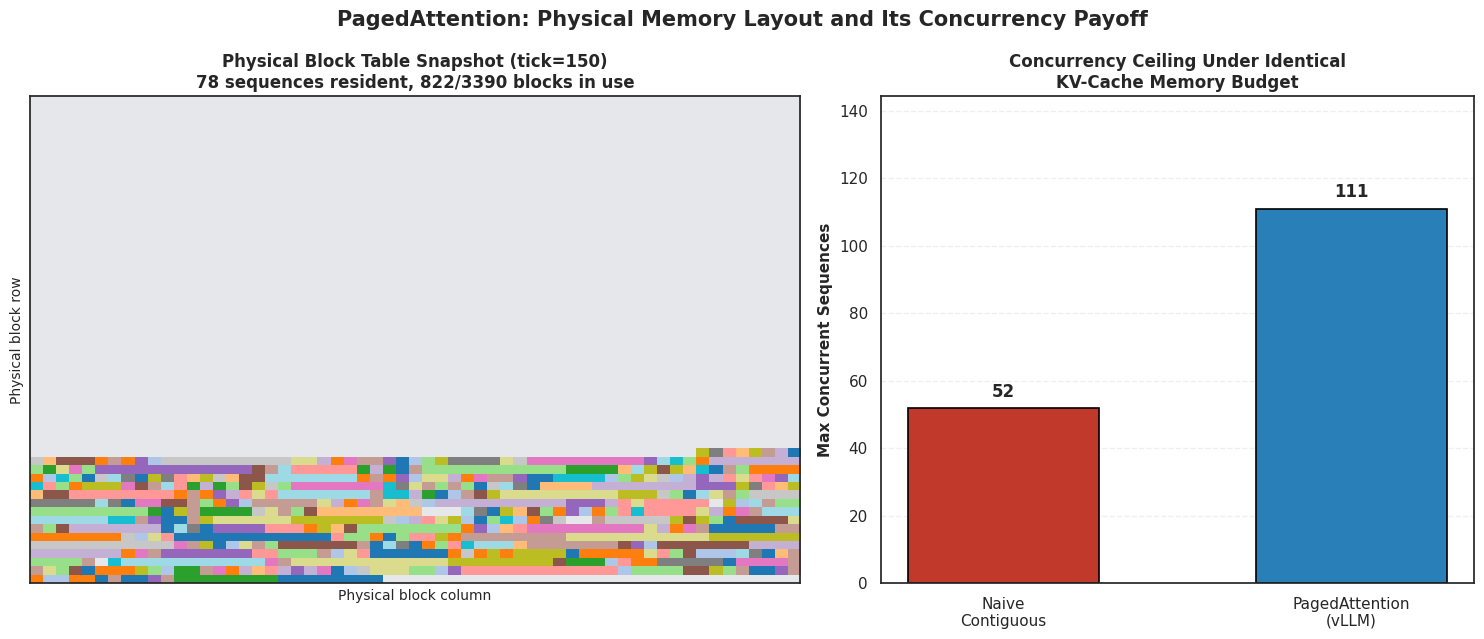

In [3]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

sns.set_theme(style="white")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={"width_ratios": [1.3, 1]})

# --- Left: physical block table snapshot as a memory-layout grid ---
owner_of_block = np.full(NUM_BLOCKS, -1, dtype=int)
for sid, blocks in snapshot.items():
    for b in blocks:
        owner_of_block[b] = sid % 18  # bucket into a small palette for readability

ncols = int(np.ceil(np.sqrt(NUM_BLOCKS)))
nrows = int(np.ceil(NUM_BLOCKS / ncols))
padded = np.full(nrows * ncols, -1, dtype=int)
padded[:NUM_BLOCKS] = owner_of_block
grid = padded.reshape(nrows, ncols)

base_cmap = plt.get_cmap("tab20", 18)
colors = ["#e5e7eb"] + [base_cmap(i) for i in range(18)]
cmap = mcolors.ListedColormap(colors)
bounds = np.arange(-1.5, 18.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

ax1.imshow(grid, cmap=cmap, norm=norm, aspect="auto")
ax1.set_title(f"Physical Block Table Snapshot (tick={SNAPSHOT_TICK})\n{len(snapshot)} sequences resident, "
              f"{NUM_BLOCKS - int((grid == -1).sum())}/{NUM_BLOCKS} blocks in use",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Physical block column", fontsize=10)
ax1.set_ylabel("Physical block row", fontsize=10)
ax1.set_xticks([])
ax1.set_yticks([])

# --- Right: concurrency comparison bar chart ---
labels = ["Naive\nContiguous", "PagedAttention\n(vLLM)"]
values = [naive_capacity, peak_concurrency]
bar_colors = ["#c0392b", "#2980b9"]
bars = ax2.bar(labels, values, color=bar_colors, width=0.55, edgecolor="black", linewidth=1.2)
ax2.set_ylabel("Max Concurrent Sequences", fontsize=11, fontweight="bold")
ax2.set_title("Concurrency Ceiling Under Identical\nKV-Cache Memory Budget", fontsize=12, fontweight="bold")
ax2.set_ylim(0, max(values) * 1.3)
for bar, v in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + max(values) * 0.03, str(v),
              ha="center", fontsize=12, fontweight="bold")
ax2.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("PagedAttention: Physical Memory Layout and Its Concurrency Payoff", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


*(Insight: the left panel is not a schematic -- it is an actual render of which sequence owns which physical block at one instant of the simulation, exactly the data structure vLLM's scheduler consults every decode iteration. The scattered, non-contiguous coloring is the point: sequences hold whatever physical blocks happen to be free, never needing a contiguous run, which is precisely what makes on-demand growth and instant freeing possible. The right panel converts that flexibility into the number that actually matters commercially: how many concurrent users one GPU can serve, given the exact same hardware and the exact same memory budget.)*

## Real-World Use Case or Analogy

Think of PagedAttention as **The Hotel Room-Block Reservation System**:

* **Naive contiguous allocation (block-booking an entire wing)**: a hotel that, whenever any guest books a stay, reserves an entire wing of rooms sized for the *longest possible stay anyone has ever booked* -- even if this particular guest checks out after one night. Almost every reserved room sits empty, but no other guest can use it, because the whole wing was set aside as one contiguous block.
* **PagedAttention (booking individual rooms as needed)**: the same hotel instead keeps a central room registry. A guest is assigned exactly as many rooms as their party currently needs; if they extend their stay, the front desk hands them one more available room -- anywhere in the building, not necessarily next door. The moment they check out, those specific rooms go straight back into the pool for the next guest.
* **Block table (the guest's key-card list)**: each guest's key cards, in order, list which physical room number corresponds to their 1st, 2nd, 3rd night, and so on -- letting housekeeping (the attention kernel) find "guest X's night 5" instantly without the rooms being physically adjacent.
* **Fragmentation bound**: the only ever-wasted space is a single partially-used room type per guest (say, a room booked for a family of four occupied by two) -- never an entire reserved-but-unused wing.
* **Continuous batching (the front desk never stops working the queue)**: the front desk doesn't wait for every current guest to check out before processing the waiting line -- the instant any single room frees up, it is offered to the next guest in the queue, every few minutes, not once a day.

**Takeaway:** the hotel that books individual rooms on demand can serve dramatically more guests per year than the hotel that reserves entire wings per booking -- with the exact same number of physical rooms. That is the entirety of vLLM's throughput advantage over static, contiguously-allocated batching.
